<a href="https://colab.research.google.com/github/io-uty/skt-pytorch/blob/main/PyTorch_FashionMNIST%EC%9D%B4%EB%AF%B8%EC%A7%80%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
%matplotlib inline

from pathlib import Path
from typing import Dict, List, Tuple
import os
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision.transforms import v2

print("torch version: " , torch.__version__)
print("torchvision version: " , torchvision.__version__)
print("cuda available:", torch.cuda.is_available())

torch version:  2.11.0+cpu
torchvision version:  0.26.0+cpu
cuda available: False


In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
  torch.backends.cudnn.benchmark = False
  torch.backends.cudnn.deterministic = True

def get_default_device() -> torch.device:
  if hasattr(torch, "accelerator") and torch.accelerator.is_available():
    return torch.device(torch.accelerator.current_accelerator().type)
  if torch.cuda.is_available():
    return torch.device("cuda")
  if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    return torch.device("mps")

  return torch.device("cpu")

device = get_default_device()
NUM_WORKERS = 0 if os.name == "nt" else 2 # 데이터 로딩 보조해주는 애들 개수
PIN_MEMORY = device.type == "cuda"        # 메모리 예약 - batch가 미리 예약된 cpu공간 사용
                                          # GPU 올리기 간편해짐
print("seed: ",SEED)
print("selected device: " , device)
print("num_workers: ", NUM_WORKERS)
print("pin_memory: ", PIN_MEMORY)

seed:  42
selected device:  cpu
num_workers:  2
pin_memory:  False


---
## FashionMNIST 분류 문제 형식화
- transform, DataLoader

#### DataLoader

- 인덱스 기반으로 샘플, 레이블 1개씩 반환
- 데이터셋을 적재시키는 역할, 순회 가능한 mini-batch stream만드는 객체

In [7]:
DATA_DIR = Path("./data")
BATCH_SIZE = 64

FASHIONMNIST_MEAN = (0.5,0.5,0.5)
FASHIONMNIST_STD = (0.5,0.5,0.5)

transform = v2.Compose([
    v2.Resize((32,32)),
    v2.Grayscale(num_output_channels=3),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(FASHIONMNIST_MEAN, FASHIONMNIST_STD)
])

dataset_start_time = time.perf_counter()

trainset = torchvision.datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=transform,
)

testset = torchvision.datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=transform,
)

dataset_elapsed = time.perf_counter() - dataset_start_time
loader_generator = torch.Generator().manual_seed(SEED)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    generator=loader_generator,
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

classes = tuple(trainset.classes)

print("dataset load/download seconds:", round(dataset_elapsed,2))
print("batch_size:", BATCH_SIZE)
print("classes:", classes)
print("train batches:", len(trainloader))
print("test batches:", len(testloader))

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.84MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 137kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.71MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.01MB/s]

dataset load/download seconds: 8.78
batch_size: 64
classes: ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')
train batches: 938
test batches: 157


## 데이터겟 크기, label 매핑, Tensor shaple 검증

In [9]:
print("trainset size:", len(trainset))
print("testset size: ", len(testset))

sample_image, sample_label = trainset[0]
print("single image shape:", tuple(sample_image.shape))
print("single image dtype:", sample_image.dtype)
print("single label index:", sample_label)
print("single label name:", classes[sample_label])

train_targets = torch.as_tensor(trainset.targets, dtype=torch.long)
test_targets = torch.as_tensor(testset.targets, dtype=torch.long)
train_counts = torch.bincount(train_targets, minlength=len(classes))
test_counts = torch.bincount(test_targets, minlength=len(classes))

print("\nclass distribution")
for idx, name in enumerate(classes):
  print(f"{idx:2d} | {name:12s} | train={int(train_counts[idx]):5d} | test={int(test_counts[idx]):4d}")

assert len(trainset) == 60_000
assert len(testset) == 10_000
assert tuple(sample_image.shape) == (3,32,32)
assert len(classes) == 10

trainset size: 60000
testset size:  10000
single image shape: (3, 32, 32)
single image dtype: torch.float32
single label index: 9
single label name: Ankle boot

class distribution
 0 | T-shirt/top  | train= 6000 | test=1000
 1 | Trouser      | train= 6000 | test=1000
 2 | Pullover     | train= 6000 | test=1000
 3 | Dress        | train= 6000 | test=1000
 4 | Coat         | train= 6000 | test=1000
 5 | Sandal       | train= 6000 | test=1000
 6 | Shirt        | train= 6000 | test=1000
 7 | Sneaker      | train= 6000 | test=1000
 8 | Bag          | train= 6000 | test=1000
 9 | Ankle boot   | train= 6000 | test=1000


## 원본 픽셀 통계와 튜토리얼 정규화

In [10]:
raw_transform = v2.Compose([
    v2.Resize((32,32)),
    v2.Grayscale(num_output_channels=3),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),

])

raw_trainset= torchvision.datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=raw_transform,
)

raw_loader = torch.utils.data.DataLoader(
    raw_trainset,
    batch_size=512,
    shuffle=False,
    num_workers = NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

def compute_channel_statistics(loader: torch.utils.data.DataLoader) -> Tuple[torch.Tensor, torch.Tensor]:
  channel_sum = torch.zeros(3)
  channel_squared_sum = torch.zeros(3)
  pixel_count = 0
  for images, _ in loader:
    channel_sum += images.sum(dim=(0, 2, 3))
    channel_squared_sum += (images ** 2).sum(dim=(0, 2, 3))
    pixel_count += images.size(0) * images.size(2) * images.size(3)
  mean = channel_sum / pixel_count
  std = (channel_squared_sum / pixel_count - mean ** 2).sqrt()
  return mean, std

estimated_mean, estimated_std = compute_channel_statistics(raw_loader)
print("estimated FashionMNIST train mean:", [round(v, 4) for v in estimated_mean.tolist()])
print("estimated FashionMNIST train std :", [round(v, 4) for v in estimated_std.tolist()])
print("tutorial mean:", FASHIONMNIST_MEAN)
print("tutorial std :", FASHIONMNIST_STD)

estimated FashionMNIST train mean: [0.2856, 0.2856, 0.2856]
estimated FashionMNIST train std : [0.3385, 0.3385, 0.3385]
tutorial mean: (0.5, 0.5, 0.5)
tutorial std : (0.5, 0.5, 0.5)


# 이미지 시각화와 mini-batch구조

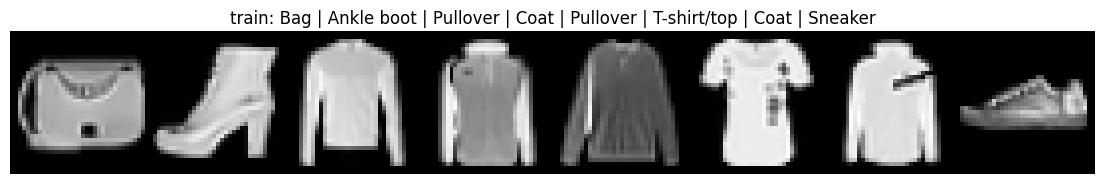

mini-batch image shape: (64, 3, 32, 32)
mini-batch label shape: (64,)
first labels: [8, 9, 2, 4, 2, 0, 4, 7]


In [11]:
def denormalize(images: torch.Tensor,
                mean: Tuple[float, float,float] = FASHIONMNIST_MEAN,
                std: Tuple[float, float,float]=FASHIONMNIST_STD) -> torch.Tensor:
    if images.ndim==3:
      mean_tensor = torch.tensor(mean, dtype=images.dtype, device=images.device).view(3,1,1)
      std_tensor = torch.tensor(std, dtype=images.dtype, device=images.device).view(3,1,1)

    elif images.ndim == 4:
      mean_tensor = torch.tensor(mean, dtype=images.dtype, device=images.device).view(1,3,1,1)
      std_tensor = torch.tensor(std, dtype=images.dtype, device=images.device).view(1,3,1,1)
    else:
      raise ValueError(f"expected 3D or 4D tensor, got shape {tuple(images.shape)}")
    return images * std_tensor + mean_tensor

def show_image_batch(images: torch.Tensor,
                     labels: torch.Tensor,
                     n: int = 8,
                     title_prefix: str = "labels") -> None:
    images = images[:n].detach().cpu()
    labels = labels[:n].detach().cpu()

    grid = torchvision.utils.make_grid(denormalize(images).clamp(0,1), nrow=n)
    np_grid = grid.numpy().transpose((1, 2, 0))
    label_text = " | ".join(classes[int(label)] for label in labels)

    plt.figure(figsize=(14,3))
    plt.imshow(np_grid)
    plt.axis("off")
    plt.title(f"{title_prefix}: {label_text}")
    plt.show()

train_images, train_labels = next(iter(trainloader))
show_image_batch(train_images, train_labels, n=8, title_prefix="train")
print("mini-batch image shape:", tuple(train_images.shape))
print("mini-batch label shape:", tuple(train_labels.shape))
print("first labels:", train_labels[:8].tolist())

---
# Convolutional Neural Network

In [30]:
class FasionMNNISTNET(nn.Module):
  def __init__(self)->None:
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
    self.fc1 = nn.Linear(in_features=16*5*5, out_features=120)
    self.fc2 = nn.Linear(in_features=120, out_features=84)
    self.fc3 = nn.Linear(in_features=84, out_features=10)

# 왜 굳이 숫자를 줄여나갈까? (120 → 84 → 10)
# 1. 최종 목적: 클래스 개수(10개)로 압축
# 2. 중간 크기(120, 84)는 "점진적으로 압축"하기 위한 설계 선택
# Conv 레이어에서 뽑아낸 400개(16×5×5)의 저수준 feature 값을
# 한 번에 10개로 확 줄이면 정보가 너무 급격하게 손실됨

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    x=  self.pool(F.relu(self.conv1(x)))
    x=  self.pool(F.relu(self.conv2(x)))
    x= torch.flatten(x, start_dim=1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

net = FasionMNNISTNET()
net.to(device)
print(net)
    # (6,28,28) -> (6,14,14) -> (16,10,10) -> (16,5,5)
    # flatten -> 16*5*5
    # 파라미터 개수 : 5*5*6+6


FasionMNNISTNET(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


## 파라미터 수와 shape 추적

In [31]:
def count_trainable_parameters(model: nn.Module) -> int:
  return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print("trainable parameters:", count_trainable_parameters(net))
x = train_images[:4].to(device)
with torch.inference_mode():
  print("input :", tuple(x.shape))
  x = net.conv1(x)
  print("conv1 :", tuple(x.shape))
  x = F.relu(x)
  print("relu1 :", tuple(x.shape))
  x = net.pool(x)
  print("pool1 :", tuple(x.shape))
  x = net.conv2(x)
  print("conv2 :", tuple(x.shape))
  x = F.relu(x)
  print("relu2 :", tuple(x.shape))
  x = net.pool(x)
  print("pool2 :", tuple(x.shape))
  x = torch.flatten(x, start_dim=1)
  print("flatten :", tuple(x.shape))
  x = F.relu(net.fc1(x))
  print("fc1 + relu :", tuple(x.shape))
  x = F.relu(net.fc2(x))
  print("fc2 + relu :", tuple(x.shape))
  x = net.fc3(x)
  print("logits :", tuple(x.shape))

  # 32*32*3 +3

trainable parameters: 62006
input : (4, 3, 32, 32)
conv1 : (4, 6, 28, 28)
relu1 : (4, 6, 28, 28)
pool1 : (4, 6, 14, 14)
conv2 : (4, 16, 10, 10)
relu2 : (4, 16, 10, 10)
pool2 : (4, 16, 5, 5)
flatten : (4, 400)
fc1 + relu : (4, 120)
fc2 + relu : (4, 84)
logits : (4, 10)


---
# 5. 손실함수와 Optimizer

In [32]:
#loss func 정의
criterion = nn.CrossEntropyLoss()
# 학습 가능 파라미터전체를 대상으로 확률적 경사하강법 적용
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum=0.9)

net.eval()
#추론모드 : gradient계산 비활성화,계산속도 증가
with torch.inference_mode():
  demo_inputs = train_images[:4].to(device)
  demo_labels = train_labels[:4].to(device)
  #신경망 net에 통과시켜 예측값 얻고
  demo_outputs = net(demo_inputs)
  demo_loss = criterion(demo_outputs, demo_labels)
  demo_probabilities = torch.softmax(demo_outputs, dim=1)

print("demo logits shape:", tuple(demo_outputs.shape))
print("demo labels shape:", tuple(demo_labels.shape))
print("demo loss:", float(demo_loss.item()))
print("softmax row sums:", [round(float(v), 4) for v in demo_probabilities.sum(dim=1).detach().cpu()])

demo logits shape: (4, 10)
demo labels shape: (4,)
demo loss: 2.2650105953216553
softmax row sums: [1.0, 1.0, 1.0, 1.0]


- TP, TN, FP, FN

-> P,N: 모델이 예
측
 : precision = TP / ( TP+FP )

 : recall (재현률) - 실제 P를 봄
 = TP / (TP+FN)

: accuracy = 실제 맞춘 경우/(전체)

-> T,F: 정답여부

---
# 6. 학습함수와 평가 함수

- 6.1학습 단계 -> 6.2평가 단계
- 파라미터 갱신이 필요하지 않음.
- model.eval() 은 dropout, batch normalization 처럼 학습/평
가 동작이 다른 계층의 모드를 전환하는 API
- torch.inference_mode() 는 gradient 계산과 autograd bookkeeping
을 비활성화해 평가 계산의 메모리 사용량과 부가 연산을 줄이는 문맥임

In [33]:
#train_one_epoch 함수 (모델 훈련)

def train_one_epoch(model : nn.Module, # 학습 신경망 모델
                    dataloader: torch.utils.data.DataLoader,
                    loss_fn: nn.Module,  # 손실함수
                    optimizer: optim.Optimizer, # 가중치 updateoptimizer
                    device: torch.device,
                    epoch: int,
                    log_interval: int = 100) -> Dict[str, float]:
    model.train() #훈련모드
    #변수초기화
    batch_losses: List[float] = []
    running_loss=0.0
    correct=0
    total=0
    start_time=time.perf_counter()
    for batch_idx, (inputs, labels) in enumerate(dataloader, start=1):
        # 미니 배치 단위로 input과 label 가져와 device로 이동
        inputs = inputs.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY)
        # 기울기 초기화 - 그라디언트 누적 x
        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        # 계산된 손실 바탕으로 파라미터 기울기 계산
        loss.backward()
        #파라미터 업데이터
        optimizer.step()
        batch_loss = float(loss.item())
        batch_losses.append(batch_loss)
        running_loss += batch_loss
        predictions = outputs.argmax(dim=1)
        correct += int((predictions == labels).sum().item())
        total += int(labels.size(0))
        #훈련 진행상황 체크
        if batch_idx % log_interval == 0:
            print(f"epoch={epoch:02d} | batch={batch_idx:04d}/{len(dataloader):04d} | mean_loss={running_loss / log_interval:.4f}")
            running_loss = 0.0
    elapsed = time.perf_counter() - start_time
    return {
        "loss": float(np.mean(batch_losses)),
        "accuracy": 100.0 * correct / max(total, 1),
        "seconds": elapsed,
    }
@torch.inference_mode()
#모델 평가 함수
def evaluate(model: nn.Module,
             dataloader: torch.utils.data.DataLoader,
             loss_fn: nn.Module,
            device: torch.device) -> Dict[str, object]:
  # 평가 모드
  model.eval()
  # 변수 초기화
  total_loss = 0.0
  correct = 0
  total = 0
  confusion = torch.zeros(len(classes), len(classes), dtype=torch.int64)
  # 데이터 순회
  for inputs, labels in dataloader:
    # 미니배치단위로 가져와 device로 이동
    inputs = inputs.to(device, non_blocking=PIN_MEMORY)
    labels = labels.to(device, non_blocking=PIN_MEMORY)
    # 예측 수행
    outputs = model(inputs)
    # 손실 계산
    loss = loss_fn(outputs, labels)
    # 성능지표 업데이트
    predictions = outputs.argmax(dim=1)
    batch_size = int(labels.size(0))
    total_loss += float(loss.item()) * batch_size
    correct += int((predictions == labels).sum().item())
    total += batch_size
    for true_label, predicted_label in zip(labels.detach().cpu(), predictions.detach().cpu()):
      confusion[int(true_label), int(predicted_label)] += 1
  return {
    "loss": total_loss / max(total, 1),
    "accuracy": 100.0 * correct / max(total, 1),
    "confusion":confusion,
  }

- 6.3 모델 학습 실행

In [34]:
# 신경망 모델 훈련, 평가하는 전체 과정
EPOCHS = 20
LOG_INTERVAL = 100
history: Dict[str, List[float]] = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
}
for epoch in range(1, EPOCHS + 1):
  # 현재 에폭동안 모델 훈련
  train_metrics = train_one_epoch(
      model=net,
      dataloader=trainloader,
      loss_fn=criterion,
      optimizer=optimizer,
      device=device,
      epoch=epoch,
      log_interval=LOG_INTERVAL,
      )
  # 훈련 끝난 후 모델의 성능 평가
  test_metrics = evaluate(net, testloader, criterion, device)
  # 각 에폭의 기록 저장
  history["epoch"].append(epoch)
  history["train_loss"].append(float(train_metrics["loss"]))
  history["train_accuracy"].append(float(train_metrics["accuracy"]))
  history["test_loss"].append(float(test_metrics["loss"]))
  history["test_accuracy"].append(float(test_metrics["accuracy"]))

  # 포맷팅하여 훈련에 걸린 시간 출력
  print(
      f"epoch={epoch:02d} | "
      f"train_loss={train_metrics['loss']:.4f} | "
      f"train_acc={train_metrics['accuracy']:.2f}% | "
      f"test_loss={test_metrics['loss']:.4f} | "
      f"test_acc={test_metrics['accuracy']:.2f}% | "
      f"time={train_metrics['seconds']:.1f}s")
print("training finished")

epoch=01 | batch=0100/0938 | mean_loss=2.3020
epoch=01 | batch=0200/0938 | mean_loss=2.2795
epoch=01 | batch=0300/0938 | mean_loss=2.1404
epoch=01 | batch=0400/0938 | mean_loss=1.3904
epoch=01 | batch=0500/0938 | mean_loss=0.9073
epoch=01 | batch=0600/0938 | mean_loss=0.8165
epoch=01 | batch=0700/0938 | mean_loss=0.7649
epoch=01 | batch=0800/0938 | mean_loss=0.7310
epoch=01 | batch=0900/0938 | mean_loss=0.6946
epoch=01 | train_loss=1.3119 | train_acc=53.86% | test_loss=0.7323 | test_acc=72.11% | time=37.3s
epoch=02 | batch=0100/0938 | mean_loss=0.6930
epoch=02 | batch=0200/0938 | mean_loss=0.6689
epoch=02 | batch=0300/0938 | mean_loss=0.6509
epoch=02 | batch=0400/0938 | mean_loss=0.6346
epoch=02 | batch=0500/0938 | mean_loss=0.6476
epoch=02 | batch=0600/0938 | mean_loss=0.6179
epoch=02 | batch=0700/0938 | mean_loss=0.5975
epoch=02 | batch=0800/0938 | mean_loss=0.6054
epoch=02 | batch=0900/0938 | mean_loss=0.6007
epoch=02 | train_loss=0.6329 | train_acc=76.20% | test_loss=0.5953 | test_

- 6.4 학습 곡선 확인

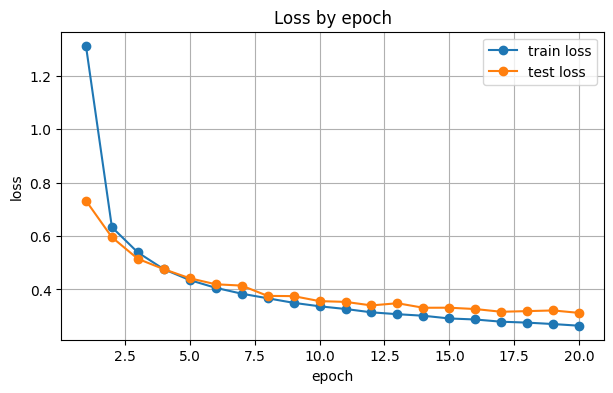

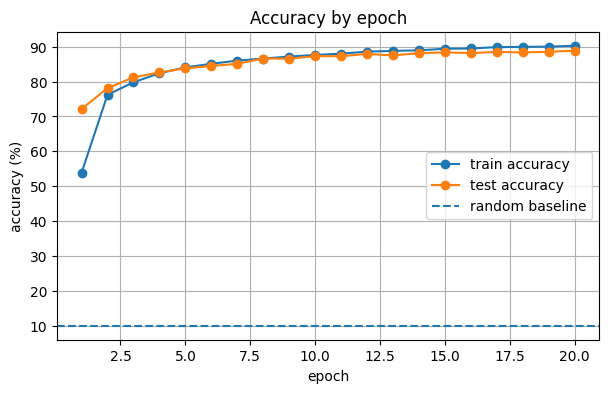

In [35]:
plt.figure(figsize=(7, 4))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="train loss")
plt.plot(history["epoch"], history["test_loss"], marker="o", label="test loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss by epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["epoch"], history["train_accuracy"], marker="o", label="train accuracy")
plt.plot(history["epoch"], history["test_accuracy"], marker="o", label="test accuracy")
plt.axhline(100 / len(classes), linestyle="--", label="random baseline")
plt.xlabel("epoch")
plt.ylabel("accuracy (%)")
plt.title("Accuracy by epoch")
plt.legend()
plt.grid(True)
plt.show()

---
# 7. 모델 저장과 복원
- 학습된 모델을 재사용하려면 파라미터를 파일로 저장해야 함.
- PyTorch 에서 일반적인 방식은 모델 전체 객체가
아니라 state_dict 를 저장하는 방식

- 7.1 state_dict
  - 계층 이름과 Tensor 파라미터를 매핑한 Python dictionary

In [36]:
MODEL_PATH = Path("./fashionmnist_cnn_state_dict.pt")

torch.save(net.state_dict(), MODEL_PATH)
print("saved model path:", MODEL_PATH.resolve())
print("saved file size MB:", round(MODEL_PATH.stat().st_size / (1024 ** 2), 4))
reloaded_net = FasionMNNISTNET().to(device)

# 예외처리
try:
  # 저장된 모델이 다른 장치에서 훈련되었더라도 현재 사용중인 device로 옮겨서 로드하도록
  state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
except TypeError:
  state_dict = torch.load(MODEL_PATH, map_location=device)
# 학습된 가중치 로드
load_result = reloaded_net.load_state_dict(state_dict)

# 모델을 평가모드로 설정
reloaded_net.eval()

print("load result:", load_result)

# 성공적으로 올라왔는지 확인
reloaded_metrics = evaluate(reloaded_net, testloader, criterion, device)
print(f"reloaded test accuracy: {reloaded_metrics['accuracy']:.2f}%")

saved model path: /content/fashionmnist_cnn_state_dict.pt
saved file size MB: 0.2407
load result: <All keys matched successfully>
reloaded test accuracy: 88.84%


---
# 8. 테스트 이미지 예측 확인

- 8.0.1

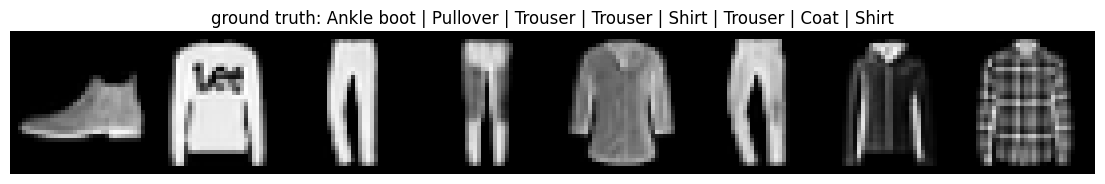

prediction results
sample=00 | true=Ankle boot | pred=Ankle boot | confidence=0.960 | correct
sample=01 | true=Pullover   | pred=Pullover   | confidence=0.998 | correct
sample=02 | true=Trouser    | pred=Trouser    | confidence=1.000 | correct
sample=03 | true=Trouser    | pred=Trouser    | confidence=1.000 | correct
sample=04 | true=Shirt      | pred=Shirt      | confidence=0.924 | correct
sample=05 | true=Trouser    | pred=Trouser    | confidence=1.000 | correct
sample=06 | true=Coat       | pred=Coat       | confidence=0.981 | correct
sample=07 | true=Shirt      | pred=Shirt      | confidence=0.943 | correct


In [37]:
test_images, test_labels = next(iter(testloader))
show_image_batch(test_images, test_labels, n=8, title_prefix="ground truth")
reloaded_net.eval()
with torch.inference_mode():
    outputs = reloaded_net(test_images[:8].to(device, non_blocking=PIN_MEMORY))
    probabilities = torch.softmax(outputs, dim=1)
    predictions = outputs.argmax(dim=1).detach().cpu()
    confidences = probabilities.max(dim=1).values.detach().cpu()
    print("prediction results")
    for idx in range(8):
        true_name = classes[int(test_labels[idx])]
        pred_name = classes[int(predictions[idx])]
        confidence = float(confidences[idx])
        mark = "correct" if true_name == pred_name else "wrong"
        print(f"sample={idx:02d} | true={true_name:10s} | pred={pred_name:10s} | confidence={confidence:.3f} | {mark}")

- 8.2 해석 기준
  - FashionMNIST 는 10 개 클래스 분류이므로 무작위 선택 기준 정확도는 약 10% 임
  - 전체 정확도는 모델의 평균적 성능을 나타내는 지표임
  - 클래스별 정확도는 특정 class 에서의 취약성을 드러내는 지표임
  - 짧은 학습과 작은 CNN 구조에서는 class 별 편차가 크게 나타날 수 있음

In [39]:
final_metrics = evaluate(reloaded_net, testloader, criterion, device)
confusion = final_metrics["confusion"]
class_totals = confusion.sum(dim=1).clamp(min=1)
class_correct = confusion.diag()
class_accuracy = 100.0 * class_correct.float() / class_totals.float()
print(f"overall test accuracy: {final_metrics['accuracy']:.2f}%")
print("\nclass-wise accuracy")
for idx, name in enumerate(classes):
  print(
    f"{idx:2d} | {name:10s} | "
    f"correct={int(class_correct[idx]):4d} / total={int(class_totals[idx]):4d} | "
    f"accuracy={float(class_accuracy[idx]):5.1f}%"
)

overall test accuracy: 88.84%

class-wise accuracy
 0 | T-shirt/top | correct= 880 / total=1000 | accuracy= 88.0%
 1 | Trouser    | correct= 970 / total=1000 | accuracy= 97.0%
 2 | Pullover   | correct= 829 / total=1000 | accuracy= 82.9%
 3 | Dress      | correct= 907 / total=1000 | accuracy= 90.7%
 4 | Coat       | correct= 770 / total=1000 | accuracy= 77.0%
 5 | Sandal     | correct= 979 / total=1000 | accuracy= 97.9%
 6 | Shirt      | correct= 681 / total=1000 | accuracy= 68.1%
 7 | Sneaker    | correct= 970 / total=1000 | accuracy= 97.0%
 8 | Bag        | correct= 963 / total=1000 | accuracy= 96.3%
 9 | Ankle boot | correct= 935 / total=1000 | accuracy= 93.5%


- 혼동행렬

rows = true labels, columns = predicted labels
tensor([[880,   0,  14,  21,   2,   1,  74,   0,   8,   0],
        [  3, 970,   0,  17,   4,   0,   4,   0,   2,   0],
        [ 18,   2, 829,   8,  67,   0,  74,   0,   2,   0],
        [ 25,   4,  17, 907,  20,   0,  26,   0,   1,   0],
        [  1,   1,  87,  48, 770,   0,  92,   0,   1,   0],
        [  1,   0,   0,   1,   0, 979,   0,  13,   0,   6],
        [172,   2,  63,  21,  52,   0, 681,   0,   9,   0],
        [  0,   0,   0,   0,   0,  20,   0, 970,   1,   9],
        [  5,   1,  11,   2,   5,   3,   6,   4, 963,   0],
        [  0,   0,   0,   0,   0,  17,   0,  48,   0, 935]])


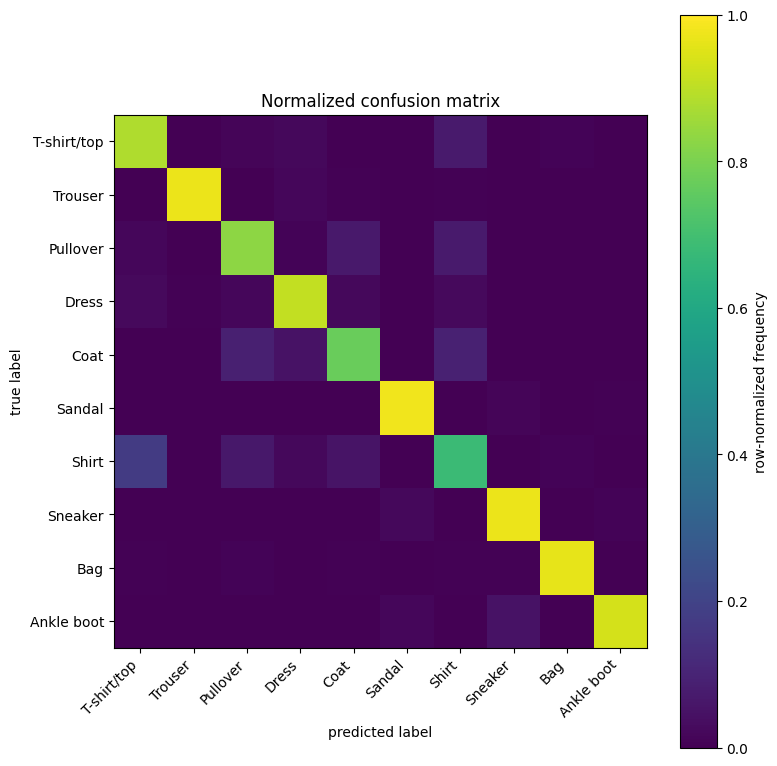

In [40]:
print("rows = true labels, columns = predicted labels")
print(confusion)
confusion_normalized = confusion.float() / confusion.sum(dim=1, keepdim=True).clamp(min=1)
plt.figure(figsize=(8, 8))
plt.imshow(confusion_normalized.numpy(), vmin=0.0, vmax=1.0)
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.title("Normalized confusion matrix")
plt.colorbar(label="row-normalized frequency")
plt.tight_layout()
plt.show()

---
# 9. 확장 실험 1: Data augmentation

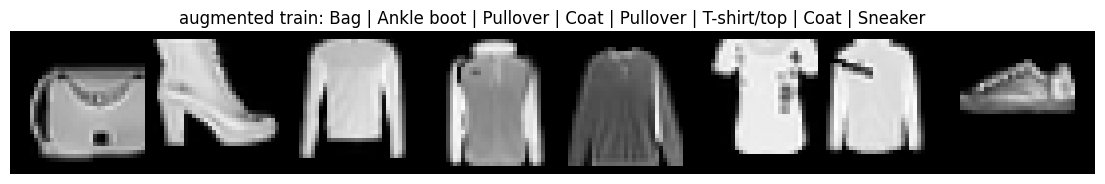

augmented batch shape: (64, 3, 32, 32)
augmented labels: [8, 9, 2, 4, 2, 0, 4, 7]


In [41]:
augmentation_transform = v2.Compose([
v2.Resize((32, 32)),
v2.Grayscale(num_output_channels=3),
v2.RandomCrop(size=32, padding=4),
v2.RandomHorizontalFlip(p=0.5),
v2.ToImage(),
v2.ToDtype(torch.float32, scale=True),
v2.Normalize(FASHIONMNIST_MEAN, FASHIONMNIST_STD),
])
augmented_trainset = torchvision.datasets.FashionMNIST(
root=str(DATA_DIR),
train=True,
download=True,
transform=augmentation_transform,
)
augmented_trainloader = torch.utils.data.DataLoader(
augmented_trainset,
batch_size=BATCH_SIZE,
shuffle=True,
num_workers=NUM_WORKERS,
pin_memory=PIN_MEMORY,
generator=torch.Generator().manual_seed(SEED),
)
augmented_images, augmented_labels = next(iter(augmented_trainloader))
show_image_batch(augmented_images, augmented_labels, n=8, title_prefix="augmented train")
print("augmented batch shape:", tuple(augmented_images.shape))
print("augmented labels:", augmented_labels[:8].tolist())

# 10 10. 확장 실험 2: 모델 폭 확장

In [43]:
class WiderFashionMNISTNet(nn.Module):
    def __init__(self, width1: int = 12, width2: int = 32) -> None:
        super().__init__()
        self.width2 = width2
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=width1, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=width1, out_channels=width2, kernel_size=5)
        self.fc1 = nn.Linear(in_features=width2 * 5 * 5, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=10) # Added missing fc3 layer

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

wide_net = WiderFashionMNISTNet(width1=12, width2=32).to(device)
print(wide_net)
print("original parameter count:", count_trainable_parameters(net))
print("wider parameter count :", count_trainable_parameters(wide_net))
with torch.inference_mode():
    dummy_output = wide_net(torch.randn(2, 3, 32, 32, device=device))
    print("dummy output shape:", tuple(dummy_output.shape))

WiderFashionMNISTNet(
  (conv1): Conv2d(3, 12, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(12, 32, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
original parameter count: 62006
wider parameter count : 117678
dummy output shape: (2, 10)
